In [1]:
# Проект e-learning: вариант 2
# Продакт-менеджер Василий попросил вас проанализировать завершенные уроки.


In [2]:
##Сначала прочитаем все таблицы и посмотрим на типы данных

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
assessments = pd.read_csv('assessments.csv')

In [3]:
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [4]:
assessments.dtypes

code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
dtype: object

In [5]:
courses = pd.read_csv('courses.csv')

In [6]:
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [7]:
courses.dtypes

code_module                   object
code_presentation             object
module_presentation_length     int64
dtype: object

In [8]:
student_assessment = pd.read_csv('studentAssessment.csv')

In [9]:
student_assessment

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


In [10]:
student_assessment.dtypes

id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

In [11]:
student_registration = pd.read_csv('studentRegistration.csv')

In [12]:
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [13]:
student_registration.dtypes

code_module             object
code_presentation       object
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

In [14]:
# Посмотрим, какие есть предметы, семестры и типы экзаменов

In [15]:
assessments.code_module.unique()

array(['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG'], dtype=object)

In [16]:
assessments.code_presentation.unique()

array(['2013J', '2014J', '2013B', '2014B'], dtype=object)

In [17]:
assessments.assessment_type.unique()

array(['TMA', 'Exam', 'CMA'], dtype=object)

In [18]:
student_assessment.isna().sum()

id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

In [19]:
# Для удобства соединим таблицу с информацией об оценках в тесте и таблицу с результатами тестов студентов

In [20]:
full_assessment = student_assessment.merge(assessments, on = 'id_assessment', how = 'inner' )


In [21]:
full_assessment

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0
...,...,...,...,...,...,...,...,...,...,...
173907,37443,527538,227,0,60.0,GGG,2014J,CMA,229.0,0.0
173908,37443,534672,229,0,100.0,GGG,2014J,CMA,229.0,0.0
173909,37443,546286,215,0,80.0,GGG,2014J,CMA,229.0,0.0
173910,37443,546724,230,0,100.0,GGG,2014J,CMA,229.0,0.0


In [22]:
full_assessment.isna().sum()

id_assessment           0
id_student              0
date_submitted          0
is_banked               0
score                 173
code_module             0
code_presentation       0
assessment_type         0
date                 2865
weight                  0
dtype: int64

In [22]:
# Теперь проанализируем данные и сформулируем, что должно сичтаться курсом. 
# По условию курс заканчивается экзаменом, значит нам нужно отобрать те записи, где тип теста - экзамен (Exam)

In [25]:
sample = full_assessment.query('assessment_type == "Exam"')
sample

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52923,24290,558914,230,0,32.0,CCC,2014B,Exam,NaN,100.0
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...
95980,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0
95981,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0
95982,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0
95983,25368,653051,242,0,27.0,DDD,2014J,Exam,NaN,100.0


In [ ]:
# Теперь посмотрим, по каким предметам были экзамены:

In [26]:
sample.code_module.unique()

array(['CCC', 'DDD'], dtype=object)

In [ ]:
# Таким образом видно, что экзамены сдавались только по предметам ССС и DDD
# Теперь сгруппируем данные по семестрам:

In [27]:
sample.groupby('code_presentation', as_index = False).agg({'code_module':'unique'})

,code_presentation,code_module
0,2013B,[DDD]
1,2013J,[DDD]
2,2014B,"[CCC, DDD]"
3,2014J,"[CCC, DDD]"


In [ ]:
# Из таблички выше видно, что в 2013 году экзамен сдавали только по предмету DDD, а в 2014 году добавился предмет CCC
# В дальнейшем будем считать курсом - факт сдачи экзамена по предметам DDD и ССС

In [24]:
#_____________________________________________________________#

In [24]:
#1.Сколько студентов успешно сдали только один курс? (Успешная сдача — это зачёт по курсу на экзамене)

In [25]:
#По условию - успешная сдача курса - это зачет по курсу на экзамене, значит нам нужно отобрать только те записи, где тип теста-
# это экзамен по курсу EXAM. Также по условию - успешная сдача теста это оценка выше 40 баллов.
#То есть score должна быть выше 40

In [26]:
exam_assessment = full_assessment.query('assessment_type == "Exam" and score >= 40')
exam_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
52928,24290,560494,230,0,92.0,CCC,2014B,Exam,NaN,100.0


In [27]:
# Однако в задани сказано, что нужно посчитать количество студентов, которые сдали только ОДИН курс. Для этого посчитаем,
# сколько каждый студент сдал экзаменов и отсортируем по возрастанию

In [28]:
number_exam = exam_assessment.groupby('id_student', as_index=False)\
             .agg({'assessment_type':'count'})\
             .rename(columns={'assessment_type':'number_of_exams'})\
             .sort_values(by='number_of_exams')

In [29]:
number_exam

,id_student,number_of_exams
0,23698,1
2694,627399,1
2695,627401,1
2696,627417,1
2697,627453,1
...,...,...
3612,1442991,2
3610,1440467,2
462,355935,2
1580,563016,2


In [30]:
#Теперь отберем только тех студентов, которые сдали только один экзамен и посчитаем их количество

In [31]:
number_exam.query('number_of_exams == 1').agg({'id_student' : 'nunique'})

id_student    3802
dtype: int64

In [32]:
#По расчетам получается, что количество студентов, успешно прошедших только один курс, равно 3802 человека.

In [33]:
#_____________________________________________________________#

In [34]:
#2. Выяви самый сложный и самый простой экзамен: найди курсы и экзамены в рамках курса,
#которые обладают самой низкой и самой высокой завершаемостью.

In [35]:
# Для начала отберем только нужные колонки

In [36]:
finished_exam = full_assessment[['id_assessment', 'score', 'code_module','assessment_type']]
finished_exam 

,id_assessment,score,code_module,assessment_type
0,1752,78.0,AAA,TMA
1,1752,70.0,AAA,TMA
2,1752,72.0,AAA,TMA
3,1752,69.0,AAA,TMA
4,1752,79.0,AAA,TMA
...,...,...,...,...
173907,37443,60.0,GGG,CMA
173908,37443,100.0,GGG,CMA
173909,37443,80.0,GGG,CMA
173910,37443,100.0,GGG,CMA


In [37]:
# По условию завершаемость = кол-во успешных экзаменов / кол-во всех попыток сдать экзамен.
# Успешная сдача - это балл выше 40. Поэтому для каждого теста посчитаем количество успешных экзаменов
# и количество всех экзаменов

In [38]:
#Количесвтво всех экзаменов:

In [39]:
all_exams = finished_exam.groupby(['id_assessment', 'assessment_type', 'code_module'], as_index = False)\
             .agg({'score':'count'})\
             .rename(columns={'score':'number_of_all_exams'})
all_exams

,id_assessment,assessment_type,code_module,number_of_all_exams
0,1752,TMA,AAA,358
1,1753,TMA,AAA,342
2,1754,TMA,AAA,330
3,1755,TMA,AAA,303
4,1756,TMA,AAA,298
...,...,...,...,...
183,37439,CMA,GGG,504
184,37440,CMA,GGG,479
185,37441,CMA,GGG,473
186,37442,CMA,GGG,416


In [40]:
#Количесвтво успешных экзаменов:

In [41]:
success_exams = finished_exam.query('score >= 40')
success_exams        

,id_assessment,score,code_module,assessment_type
0,1752,78.0,AAA,TMA
1,1752,70.0,AAA,TMA
2,1752,72.0,AAA,TMA
3,1752,69.0,AAA,TMA
4,1752,79.0,AAA,TMA
...,...,...,...,...
173907,37443,60.0,GGG,CMA
173908,37443,100.0,GGG,CMA
173909,37443,80.0,GGG,CMA
173910,37443,100.0,GGG,CMA


In [42]:
success_exams = success_exams.groupby(['id_assessment', 'assessment_type', 'code_module'], as_index = False)\
             .agg({'score':'count'})\
             .rename(columns={'score':'number_of_success_exams'})
success_exams

,id_assessment,assessment_type,code_module,number_of_success_exams
0,1752,TMA,AAA,352
1,1753,TMA,AAA,330
2,1754,TMA,AAA,325
3,1755,TMA,AAA,294
4,1756,TMA,AAA,290
...,...,...,...,...
183,37439,CMA,GGG,503
184,37440,CMA,GGG,466
185,37441,CMA,GGG,470
186,37442,CMA,GGG,396


In [43]:
# Теперь соединим две таблицы и посчитаем завершаемость

In [44]:
finished = all_exams.merge(success_exams, on = ['id_assessment','assessment_type', 'code_module'], how = 'outer')

In [45]:
finished

,id_assessment,assessment_type,code_module,number_of_all_exams,number_of_success_exams
0,1752,TMA,AAA,358,352
1,1753,TMA,AAA,342,330
2,1754,TMA,AAA,330,325
3,1755,TMA,AAA,303,294
4,1756,TMA,AAA,298,290
...,...,...,...,...,...
183,37439,CMA,GGG,504,503
184,37440,CMA,GGG,479,466
185,37441,CMA,GGG,473,470
186,37442,CMA,GGG,416,396


In [46]:
# Добавим колонку с завершаемостью и отсортируем по возратстанию

In [47]:
finished['finish_score'] = finished['number_of_success_exams']/finished['number_of_all_exams']
finished = finished.sort_values('finish_score').query('assessment_type == "Exam"')
finished

,id_assessment,assessment_type,code_module,number_of_all_exams,number_of_success_exams,finish_score
72,25340,Exam,DDD,602,504,0.837209
65,24299,Exam,CCC,1168,1019,0.872432
100,25368,Exam,DDD,950,842,0.886316
56,24290,Exam,CCC,747,664,0.888889
86,25354,Exam,DDD,968,878,0.907025
93,25361,Exam,DDD,524,485,0.925573


In [48]:
# Из таблицы видно, что самой низкой завершаемостью в рамках курса обладает тест с id = 25340 по предмету DDD,
# то есть этот экзамен является самым сложным. Самым легким является экзамен с id = 25361 по предмету DDD

In [49]:
#_____________________________________________________________#

In [50]:
# 3. По каждому предмету определи средний срок сдачи экзаменов 
# (под сдачей понимаем последнее успешное прохождение экзамена студентом).

In [51]:
# Так как под сдачей мы понимаем последнее успешное прохождение экзамена студентом, то отберем только те записи, где оценка 
# score > 40 и тип теста Exam:

In [52]:
module_assessment = full_assessment.query('assessment_type == "Exam" and score >= 40')
module_assessment

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
52928,24290,560494,230,0,92.0,CCC,2014B,Exam,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...
95978,25368,652617,243,0,56.0,DDD,2014J,Exam,NaN,100.0
95980,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0
95981,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0
95982,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0


In [53]:
# Из полученной таблицы видно, что экзамены сдавались только по предметам CCC и DDD, для них  посчитаем среднее время сдачи
# для каждого семестра отдельно

In [54]:
module_assessment.groupby(['id_assessment', 'code_module', 'code_presentation'], as_index=False)\
                 .agg({'date_submitted':'mean'})\
                 .rename(columns={'date_submitted':'average_date_submitted'})


,id_assessment,code_module,code_presentation,average_date_submitted
0,24290,CCC,2014B,231.581325
1,24299,CCC,2014J,244.404318
2,25340,DDD,2013B,230.164683
3,25354,DDD,2013J,239.509112
4,25361,DDD,2014B,234.936082
5,25368,DDD,2014J,242.804038


In [55]:
#_____________________________________________________________#

In [56]:
# 4.Выяви самые популярные предметы (ТОП-3) по количеству регистраций на них.
# А также предметы с самым большим оттоком (ТОП-3).

In [57]:
student_registration

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN
...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,NaN
32589,GGG,2014J,2645731,-23.0,NaN
32590,GGG,2014J,2648187,-129.0,NaN
32591,GGG,2014J,2679821,-49.0,101.0


In [58]:
# Для того, чтобы выявить самые популярные предметы, сгруппируем данные по коду предмета, посчитаем количество 
# регистраций на них и отсортируем по убыванию

In [59]:
popular_module = student_registration.groupby('code_module', as_index=False)\
                                    .agg({'id_student':'count'})\
                                    .rename(columns={'id_student':'number_of_registrations'})\
                                    .sort_values('number_of_registrations', ascending=False)
popular_module

,code_module,number_of_registrations
1,BBB,7909
5,FFF,7762
3,DDD,6272
2,CCC,4434
4,EEE,2934
6,GGG,2534
0,AAA,748


In [60]:
# Из таблицы видно, что самыми популярными предметами являются BBB, FFF, DDD

In [61]:
# Для того, чтобы выявить предметы с самым большим оттоком отберем только те данные, где  дата отмены регистрации
# студента с предмета не равна NaN (так как по условию, если стоит Nan - значит студент закончил курс)

In [62]:
unpopular_module = student_registration.query('date_unregistration != "NaN"')
unpopular_module

,code_module,code_presentation,id_student,date_registration,date_unregistration
2,AAA,2013J,30268,-92.0,12.0
15,AAA,2013J,65002,-180.0,96.0
22,AAA,2013J,94961,-170.0,72.0
29,AAA,2013J,106247,5.0,175.0
41,AAA,2013J,129955,-197.0,135.0
...,...,...,...,...,...
32576,GGG,2014J,2338614,-23.0,58.0
32577,GGG,2014J,2342238,-45.0,74.0
32578,GGG,2014J,2357806,-128.0,73.0
32586,GGG,2014J,2608143,-45.0,48.0


In [63]:
# Для того, чтобы выявить самые непопулярные предметы, также сгруппируем данные по коду предмета, посчитаем количество 
# отмен регистраций на них и отсортируем по убыванию

In [64]:
unpopular_module = unpopular_module.groupby('code_module', as_index=False)\
                                    .agg({'id_student':'count'})\
                                    .rename(columns={'id_student':'number_of_unregistrations'})\
                                    .sort_values('number_of_unregistrations', ascending=False)
unpopular_module

,code_module,number_of_unregistrations
5,FFF,2380
1,BBB,2377
3,DDD,2235
2,CCC,1947
4,EEE,718
6,GGG,289
0,AAA,126


In [65]:
# Из таблицы видно, что самыми популярными предметами являются FFF, BBB, DDD

In [66]:
#_____________________________________________________________#

In [67]:
# 5. Используя pandas, в период с начала 2013 по конец 2014 выяви семестр с самой низкой завершаемостью курсов
# и самыми долгими средними сроками сдачи курсов. 

In [68]:
# Для начала посмотрим, сколько есть семестров и каке они

In [69]:
assessments.code_presentation.unique()

array(['2013J', '2014J', '2013B', '2014B'], dtype=object)

In [70]:
# Получается, что у нас есть 4 семестра

In [71]:
# Теперь сгруппируем данные по семестрам и типу теста(нам нужен Exam), посчитаем количество всех экзаменов, переименуем
# колонку и отберем только те данные, где тип теста - Exam

In [72]:
semestr_all_exams = full_assessment.groupby(['code_presentation', 'assessment_type'], as_index = False)\
             .agg({'score':'count'})\
             .rename(columns={'score':'number_of_all_exams'})
semestr_all_exams = semestr_all_exams.query('assessment_type == "Exam"')
semestr_all_exams

,code_presentation,assessment_type,number_of_all_exams
1,2013B,Exam,602
4,2013J,Exam,968
7,2014B,Exam,1271
10,2014J,Exam,2118


In [73]:
# Для подсчета успешных экзаменов отберем только те данные, где тип экзамена Exam и оценка выше 40 баллов:

In [74]:
semestr_success_exams = full_assessment.query('score >= 40 and assessment_type == "Exam"')
semestr_success_exams


,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
52928,24290,560494,230,0,92.0,CCC,2014B,Exam,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...
95978,25368,652617,243,0,56.0,DDD,2014J,Exam,NaN,100.0
95980,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0
95981,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0
95982,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0


In [75]:
semestr_success_exams = semestr_success_exams.groupby(['code_presentation'], as_index = False)\
             .agg({'score':'count'})\
             .rename(columns={'score':'number_of_success_exams'})
semestr_success_exams

,code_presentation,number_of_success_exams
0,2013B,504
1,2013J,878
2,2014B,1149
3,2014J,1861


In [76]:
# Теперь соединим две таблицы и посчитаем завершаемость

In [77]:
all_semestr = semestr_all_exams.merge(semestr_success_exams, on = ['code_presentation'], how = 'outer')

In [78]:
all_semestr

,code_presentation,assessment_type,number_of_all_exams,number_of_success_exams
0,2013B,Exam,602,504
1,2013J,Exam,968,878
2,2014B,Exam,1271,1149
3,2014J,Exam,2118,1861


In [79]:
# Добавим колонку с завершаемостью

In [80]:
all_semestr['finish_score'] = all_semestr['number_of_success_exams']/all_semestr['number_of_all_exams']
all_semestr

,code_presentation,assessment_type,number_of_all_exams,number_of_success_exams,finish_score
0,2013B,Exam,602,504,0.837209
1,2013J,Exam,968,878,0.907025
2,2014B,Exam,1271,1149,0.904013
3,2014J,Exam,2118,1861,0.878659


In [81]:
# таким образом, получается, что семестр с самой низко завершаемостью - 2013B

In [82]:
# Теперь определеим семестр с самыми долгими средними сроками сдачи курсов

In [83]:
date_as = full_assessment.query('assessment_type == "Exam"')
date_as

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52923,24290,558914,230,0,32.0,CCC,2014B,Exam,NaN,100.0
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...
95980,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0
95981,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0
95982,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0
95983,25368,653051,242,0,27.0,DDD,2014J,Exam,NaN,100.0


In [84]:
date_as.groupby(['code_module', 'code_presentation'], as_index=False)\
       .agg({'date_submitted':'mean'})\
       .rename(columns={'date_submitted':'avg_date'})\
       .sort_values('avg_date')

,code_module,code_presentation,avg_date
2,DDD,2013B,230.179402
0,CCC,2014B,231.617135
4,DDD,2014B,234.944656
3,DDD,2013J,239.505165
5,DDD,2014J,242.791579
1,CCC,2014J,244.392123


In [85]:
# Из таблицы видно, что самые долги средние сроки сдачи курсов и семестра 2014J

In [86]:
#_____________________________________________________________#

In [87]:
# 6. Для качественного анализа аудитории применим RFM - анализ. Этот подход основан на сегментации.
# В адапртированной кластеризации выберем следующие метрики:
# R - среднее время сдачи одного экзамена
# F - завершаемость курсов 
# M - среднее количество баллов


In [88]:
# Для начала отберем из таблицы full_assessment только тех студентов, которые сдавали экзамен (assessment_type = Exam)

In [89]:
RFM = full_assessment.query('assessment_type == "Exam"')
RFM

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
52923,24290,558914,230,0,32.0,CCC,2014B,Exam,NaN,100.0
52924,24290,559706,234,0,78.0,CCC,2014B,Exam,NaN,100.0
52925,24290,559770,230,0,54.0,CCC,2014B,Exam,NaN,100.0
52926,24290,560114,230,0,64.0,CCC,2014B,Exam,NaN,100.0
52927,24290,560311,234,0,100.0,CCC,2014B,Exam,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...
95980,25368,652680,243,0,91.0,DDD,2014J,Exam,NaN,100.0
95981,25368,652732,249,0,47.0,DDD,2014J,Exam,NaN,100.0
95982,25368,652965,242,0,87.0,DDD,2014J,Exam,NaN,100.0
95983,25368,653051,242,0,27.0,DDD,2014J,Exam,NaN,100.0


In [90]:
# Затем сгруппируем данные по студентам, поситчаем среднее время сдачи экзаменов и среднюю оценку на экзамене.
# Переименуем колонки и получим, что Recency - это среднее время сдачи одного экзамена, Monetary - средний балл за экзамен

In [91]:
RFM = RFM.groupby('id_student', as_index = False)\
         .agg({'date_submitted': 'mean', 'score':'mean'})\
         .rename(columns={'date_submitted':'Recency', 'score':'Monetary'}) 
RFM         

,id_student,Recency,Monetary
0,23698,243.0,80.0
1,24213,236.0,58.0
2,27116,243.0,96.0
3,28046,237.0,40.0
4,28787,243.0,44.0
...,...,...,...
4628,2694886,236.0,69.0
4629,2694933,230.0,73.0
4630,2695608,237.0,73.0
4631,2697181,230.0,80.0


In [92]:
# Для расчета завершаемости курсов разделим значение оценки на максимальное количество баллов(100), 
# и тогда получим колонку Frequency - завершаемость курсов

In [93]:
RFM['Frequency'] = RFM.Monetary / 100

In [94]:
RFM = RFM.reindex(columns=['id_student', 'Recency', 'Frequency', 'Monetary'])

In [95]:
RFM

,id_student,Recency,Frequency,Monetary
0,23698,243.0,0.80,80.0
1,24213,236.0,0.58,58.0
2,27116,243.0,0.96,96.0
3,28046,237.0,0.40,40.0
4,28787,243.0,0.44,44.0
...,...,...,...,...
4628,2694886,236.0,0.69,69.0
4629,2694933,230.0,0.73,73.0
4630,2695608,237.0,0.73,73.0
4631,2697181,230.0,0.80,80.0


In [96]:
# Теперь для разделения аудитории на сегменты, проранжируем каждый параметр Recency, Frequency, Monetary.

# Разделим параметр Recency (среднее время сдачи экзаменов) на 5 групп: для этого используем квантили (20, 40, 60 и 80 %), 
# то есть каждый квантиль содержит 20 % студентов.

# Параметр Frequency (завершаемость курсов) разделим на 2 части: больше и меньше 0.4. То есть студент либо завершил курс,
# сдав экзамен, либо не завершил.

# Параметр Monetary (средний балл за экзамен) сами разделим на 5 частей: 1 группа - те, кто набрали < 40 баллов, 
# 2 группа: 40-65 баллов, 3 группа: 65-75 баллов, 4 группа: 75-85 баллов, 5 группа: больше 85 баллов

In [97]:
quintiles = RFM[['Recency']].quantile([.2, .4, .6, .8]).to_dict()
quintiles

{'Recency': {0.2: 231.0, 0.4: 237.0, 0.6: 242.0, 0.8: 243.5}}

In [98]:
def r_score(x):
    if x <= quintiles['Recency'][.2]:
        return 5
    elif x <= quintiles['Recency'][.4]:
        return 4
    elif x <= quintiles['Recency'][.6]:
        return 3
    elif x <= quintiles['Recency'][.8]:
        return 2
    else:
        return 1
    
def f_score(x):  
    if x < 0.4:
        return 0
    else: return 1

def m_score(x):
    if x < 40:
        return 1
    elif x <= 65:
        return 2
    elif x <= 75:
        return 3
    elif x <= 85:
        return 4
    else:
        return 5    


RFM['R'] = RFM['Recency'].apply(lambda x: r_score(x))
RFM['F'] = RFM['Frequency'].apply(lambda x: f_score(x))
RFM['M'] = RFM['Monetary'].apply(lambda x: m_score(x))

In [99]:
RFM

,id_student,Recency,Frequency,Monetary,R,F,M
0,23698,243.0,0.80,80.0,2,1,4
1,24213,236.0,0.58,58.0,4,1,2
2,27116,243.0,0.96,96.0,2,1,5
3,28046,237.0,0.40,40.0,4,1,2
4,28787,243.0,0.44,44.0,2,1,2
...,...,...,...,...,...,...,...
4628,2694886,236.0,0.69,69.0,4,1,3
4629,2694933,230.0,0.73,73.0,5,1,3
4630,2695608,237.0,0.73,73.0,4,1,3
4631,2697181,230.0,0.80,80.0,5,1,4


In [100]:
# Теперь создадим новую колонку RFM - параметр, каждый из которых даст нам уникальную комбинацию сегмента

In [101]:
RFM['RFM Score'] = RFM['R'].map(str) + RFM['F'].map(str) + RFM['M'].map(str)

In [102]:
RFM

,id_student,Recency,Frequency,Monetary,R,F,M,RFM Score
0,23698,243.0,0.80,80.0,2,1,4,214
1,24213,236.0,0.58,58.0,4,1,2,412
2,27116,243.0,0.96,96.0,2,1,5,215
3,28046,237.0,0.40,40.0,4,1,2,412
4,28787,243.0,0.44,44.0,2,1,2,212
...,...,...,...,...,...,...,...,...
4628,2694886,236.0,0.69,69.0,4,1,3,413
4629,2694933,230.0,0.73,73.0,5,1,3,513
4630,2695608,237.0,0.73,73.0,4,1,3,413
4631,2697181,230.0,0.80,80.0,5,1,4,514


In [103]:
# Всего у нас получилось: 5*5*2 = 50 комбинаций, но мы сгруппируем их в 6 сегментов, которые предствлены на картинке ниже:
# Скоростной отличник - студенты, которые набрали высокий балл (больше 85) с минимальным средним временем сдачи экзамена
# Отличник - студенты, которые набрали высокий балл (больше 85), но время сдачи экзамена больше 237 дней (0.4 квантиль)
# Скоростной хорошист - студенты, которые набрали менее выскоий балл (65-85)с минимальным средним временем сдачи экзамена
# Хорошист - студенты, которые набрали менее выскоий балл (65-85), но время сдачи экзамена больше 237 дней (0.4 квантиль)
# Пограничные - студенты, которые набрали пограничный балл (40-65) при любом времени сдачи экзамена
# Неуспевающие - студенты, которые не набрали 40 баллов на экзамене


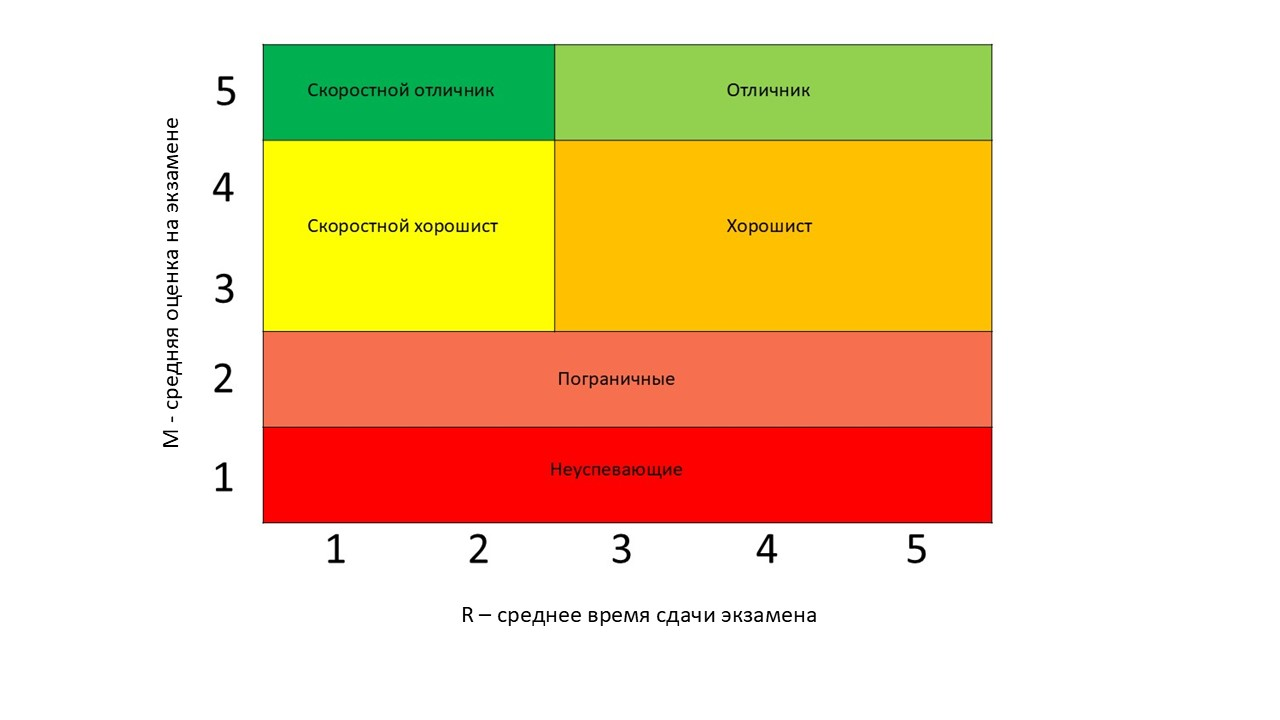

In [104]:
from IPython.display import Image
Image('Segments.jpg')

In [105]:
segt_map = {
    r'[1-2]15': 'Успевающие отличники',
    r'[3-5]15': 'Отличники',
    r'[1-2]1[3-4]': 'Успевающие хорошисты',
    r'[3-5]1[3-4]': 'Хорошисты',
    r'[1-5]12': 'Пограничные',
    r'[1-5]01': 'Неуспевающие',
    }

RFM['Segment'] = RFM['R'].map(str) + RFM['F'].map(str) + RFM['M'].map(str)
RFM['Segment'] = RFM['Segment'].replace(segt_map, regex=True)
RFM

,id_student,Recency,Frequency,Monetary,R,F,M,RFM Score,Segment
0,23698,243.0,0.80,80.0,2,1,4,214,Успевающие хорошисты
1,24213,236.0,0.58,58.0,4,1,2,412,Пограничные
2,27116,243.0,0.96,96.0,2,1,5,215,Успевающие отличники
3,28046,237.0,0.40,40.0,4,1,2,412,Пограничные
4,28787,243.0,0.44,44.0,2,1,2,212,Пограничные
...,...,...,...,...,...,...,...,...,...
4628,2694886,236.0,0.69,69.0,4,1,3,413,Хорошисты
4629,2694933,230.0,0.73,73.0,5,1,3,513,Хорошисты
4630,2695608,237.0,0.73,73.0,4,1,3,413,Хорошисты
4631,2697181,230.0,0.80,80.0,5,1,4,514,Хорошисты


In [106]:
# Теперь посмотрим, сколько в каждом сегменте студентов и построим гистограмму распределения

In [107]:
RFM.Segment.value_counts()

Пограничные             1756
Хорошисты                984
Неуспевающие             543
Отличники                514
Успевающие хорошисты     446
Успевающие отличники     390
Name: Segment, dtype: int64

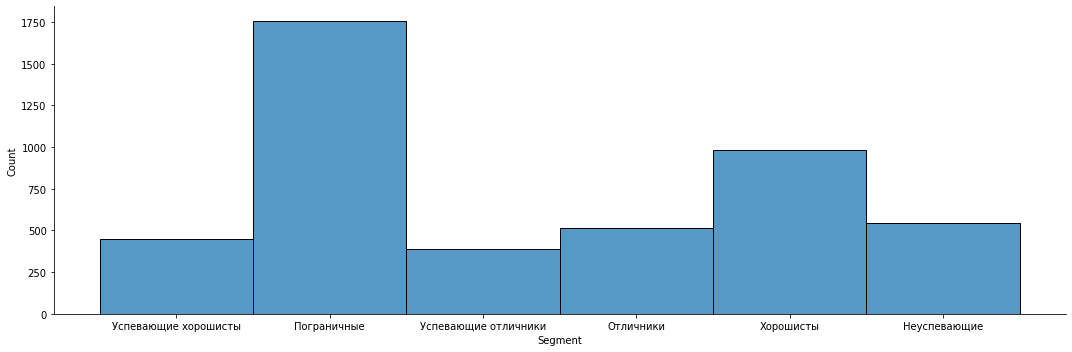

In [119]:

sns.displot(x= 'Segment', data = RFM, aspect = 3)


In [ ]:
# Из графика выше видно, что студентов, которые набрали пограничный балл почти в два раза выше, чем все остальные категории.
# Также заметно отклоняется группа студентов - хорошисты, остальны группы примерно на одном уровне.